<a href="https://colab.research.google.com/github/avram4uk/coursework/blob/main/%D0%B3%D0%BB%D0%B0%D0%B2%D0%B0_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/AirQuality.csv'
df = pd.read_csv(file_path, sep=';', decimal=',')

print("Первые 5 строк данных:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print(f"\nРазмерность данных: {df.shape}")

# Преобразование в datetime и установка индекса
# Объединяем столбцы Date и Time в один
df['DateTime'] = df['Date'] + ' ' + df['Time']

# Конвертируем в datetime (указываем формат)
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H.%M.%S')

# Устанавливаем как индекс
df.set_index('DateTime', inplace=True)

# Удаляем уже ненужные столбцы Date и Time
df.drop(columns=['Date', 'Time'], inplace=True)

# Проверяем результат
print(f"\nПервые строки с новым индексом:")
print(df.head())

Первые 5 строк данных:
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN         

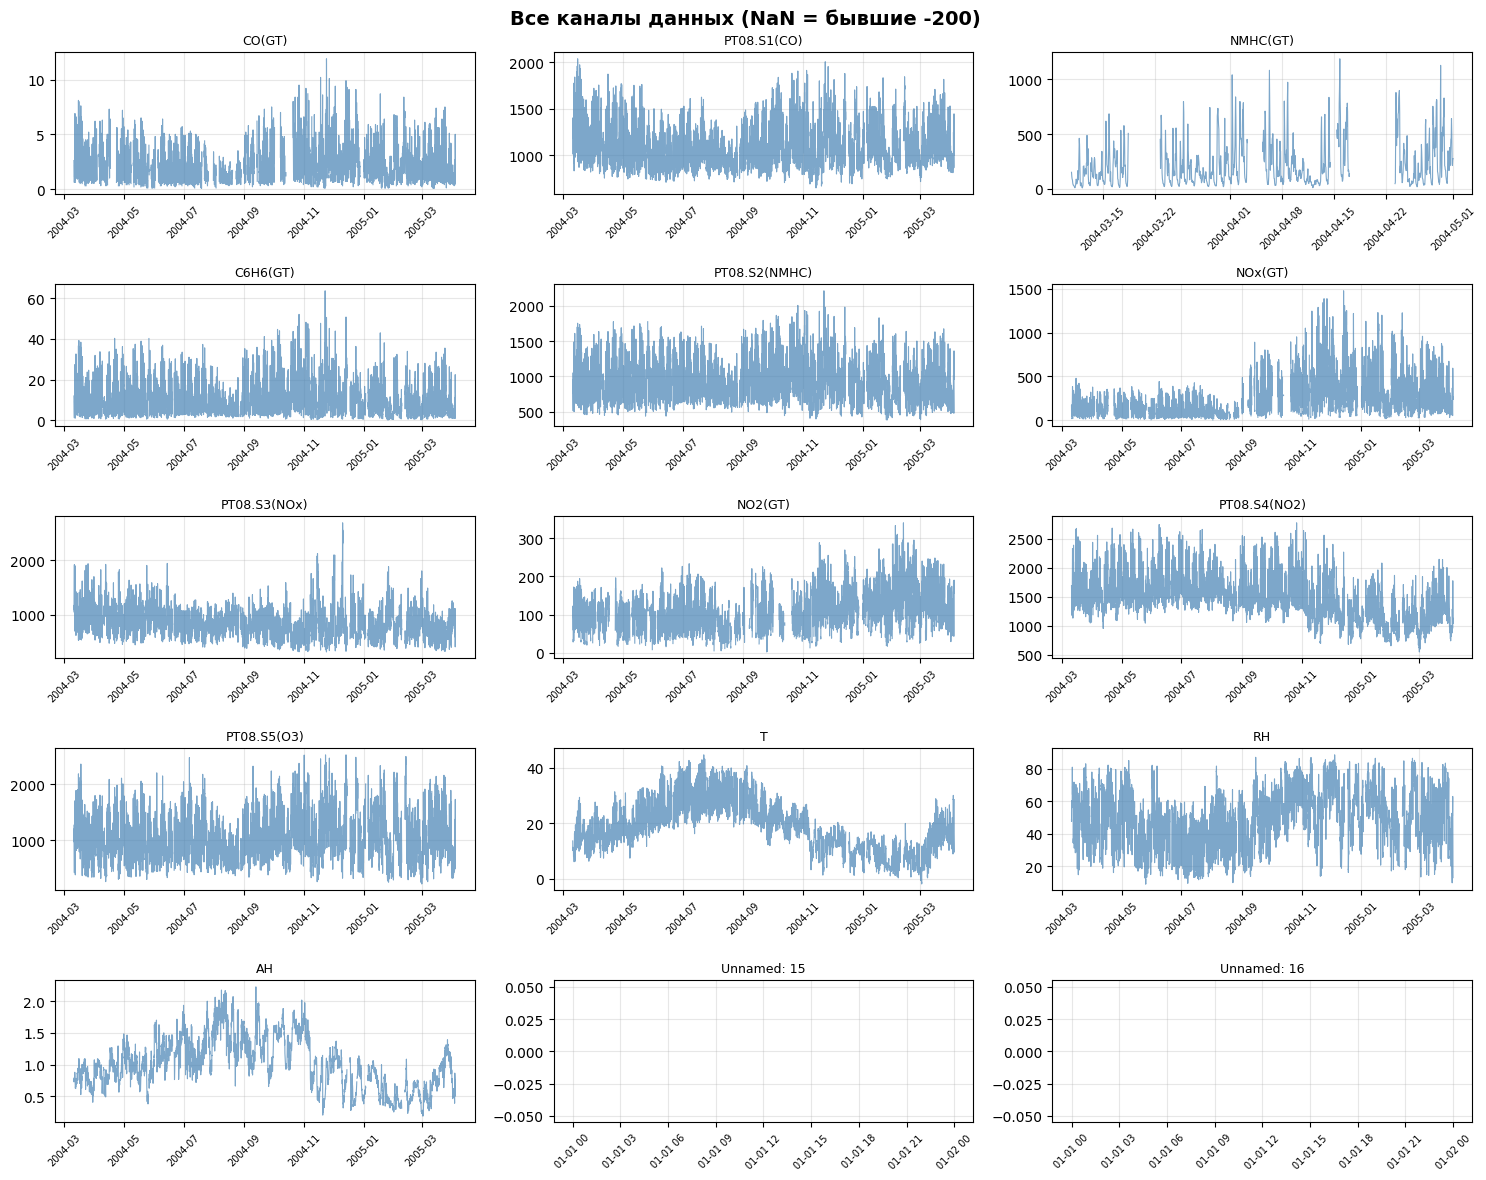

In [ ]:
# Загрузка и подготовка
df = df.replace(-200, np.nan)  # Исключаем -200

# Быстрая визуализация всех каналов в одном окне
fig, axes = plt.subplots(5, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    axes[idx].plot(df.index, df[col], linewidth=0.8, color='steelblue', alpha=0.7)
    axes[idx].set_title(col, fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Все каналы данных (NaN = бывшие -200)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# будем исключать значения равные -200 при расчёте статистик
# Функция для расчёта статистик по каналу, исключая значения равные -200
def calculate_stats_excluding_missing(series, missing_value=-200.0):
    """
    Рассчитывает статистики для ряда, исключая значения, равные missing_value
    """
    # Фильтруем: оставляем только значения, не равные missing_value
    clean_series = series[series != missing_value]

    # Если после фильтрации нет данных
    if len(clean_series) == 0:
        return {
            'count': 0,
            'mean': np.nan,
            'std': np.nan,
            'min': np.nan,
            'q1': np.nan,
            'median': np.nan,
            'q3': np.nan,
            'max': np.nan
        }

    # Расчёт статистик
    return {
        'count': len(clean_series),
        'mean': clean_series.mean(),
        'std': clean_series.std(),
        'min': clean_series.min(),
        'q1': clean_series.quantile(0.25),
        'median': clean_series.median(),
        'q3': clean_series.quantile(0.75),
        'max': clean_series.max()
    }


stats_dict = {}
for column in df.columns:
    stats_dict[column] = calculate_stats_excluding_missing(df[column])


stats_table = pd.DataFrame(stats_dict).T
stats_table = stats_table.round(4)
stats_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']

print("\nСтатистические характеристики каналов (значения равные -200 исключены):")
print(stats_table.to_string())




Статистические характеристики каналов (значения равные -200 исключены):
                Count       Mean       Std       Min         Q1     Median         Q3       Max
CO(GT)         9471.0     2.1527    1.4533    0.1000     1.1000     1.8000     2.9000    11.900
PT08.S1(CO)    9471.0  1099.8332  217.0800  647.0000   937.0000  1063.0000  1231.0000  2040.000
NMHC(GT)       9471.0   218.8118  204.4599    7.0000    67.0000   150.0000   297.0000  1189.000
C6H6(GT)       9471.0    10.0831    7.4498    0.1000     4.4000     8.2000    14.0000    63.700
PT08.S2(NMHC)  9471.0   939.1534  266.8314  383.0000   734.5000   909.0000  1116.0000  2214.000
NOx(GT)        9471.0   246.8967  212.9792    2.0000    98.0000   180.0000   326.0000  1479.000
PT08.S3(NOx)   9471.0   835.4936  256.8173  322.0000   658.0000   806.0000   969.5000  2683.000
NO2(GT)        9471.0   113.0913   48.3701    2.0000    78.0000   109.0000   142.0000   340.000
PT08.S4(NO2)   9471.0  1456.2646  346.2068  551.0000  1227.0000

Доля пропущенных значений по каналам:
        Канал  Доля пропусков (%)  Количество пропусков
  Unnamed: 15          100.000000                  9471
  Unnamed: 16          100.000000                  9471
     NMHC(GT)           90.349488                  8557
       CO(GT)           18.973709                  1797
      NO2(GT)           18.540809                  1756
      NOx(GT)           18.509133                  1753
  PT08.S1(CO)            5.068103                   480
 PT08.S3(NOx)            5.068103                   480
PT08.S2(NMHC)            5.068103                   480
     C6H6(GT)            5.068103                   480
 PT08.S4(NO2)            5.068103                   480
            T            5.068103                   480
  PT08.S5(O3)            5.068103                   480
           AH            5.068103                   480
           RH            5.068103                   480


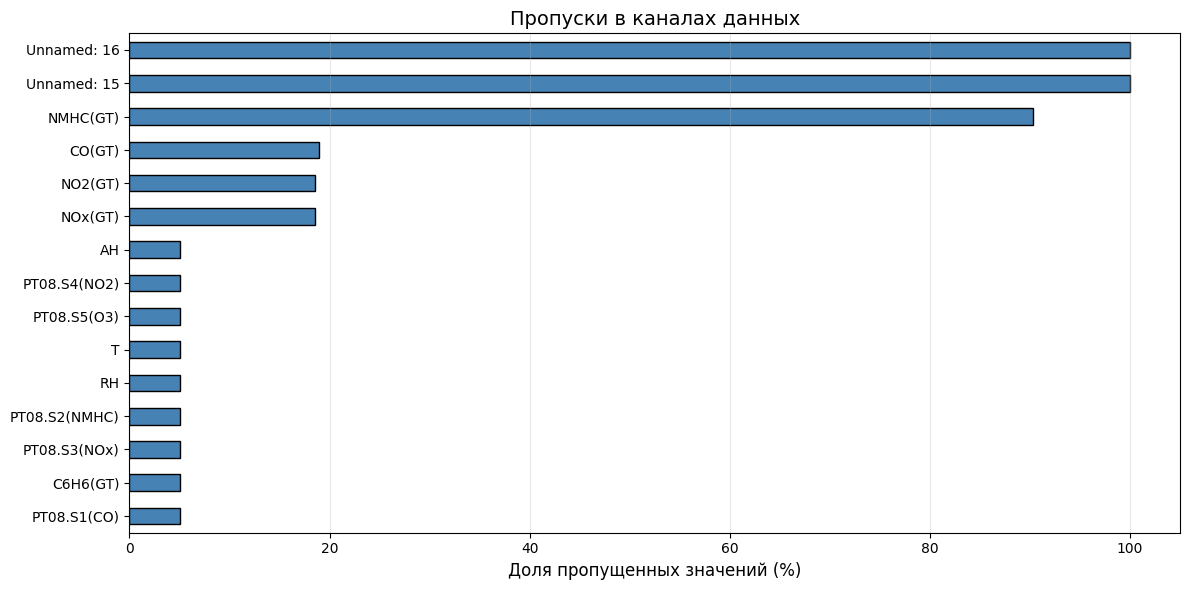

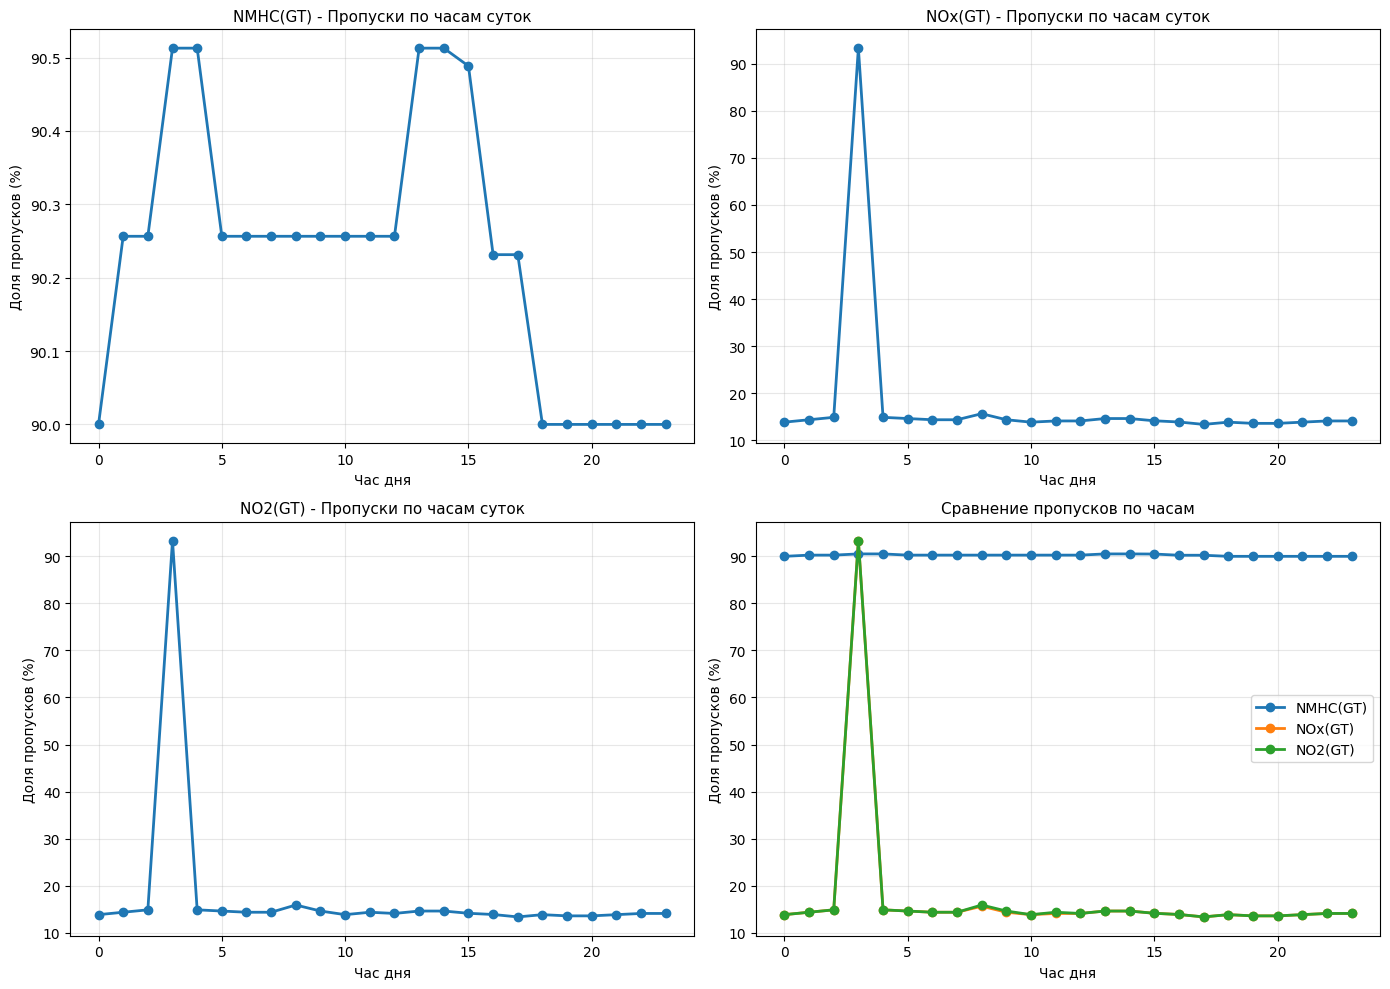

Выбросы по правилу трёх сигм:
        Канал  Выбросов (3σ)  Доля выбросов (%)                         Примеры выбросов
      NOx(GT)            138               1.79     [891.0, 895.0, 918.0, 952.0, 1052.0]
       CO(GT)            102               1.33                [6.9, 6.6, 8.1, 8.0, 6.6]
     C6H6(GT)            118               1.31           [32.6, 36.7, 39.2, 36.4, 38.4]
 PT08.S3(NOx)            109               1.21 [1705.0, 1818.0, 1918.0, 1738.0, 1680.0]
     NMHC(GT)             11               1.20    [1042.0, 840.0, 1084.0, 974.0, 836.0]
  PT08.S1(CO)             60               0.67 [1776.0, 1843.0, 1808.0, 1898.0, 1797.0]
      NO2(GT)             48               0.62      [272.0, 288.0, 267.0, 282.0, 278.0]
 PT08.S4(NO2)             38               0.42 [2665.0, 2679.0, 2535.0, 2560.0, 2684.0]
PT08.S2(NMHC)             37               0.41 [1754.0, 1776.0, 1748.0, 1776.0, 1795.0]
  PT08.S5(O3)             37               0.41 [2306.0, 2359.0, 2475.0, 2321.0,

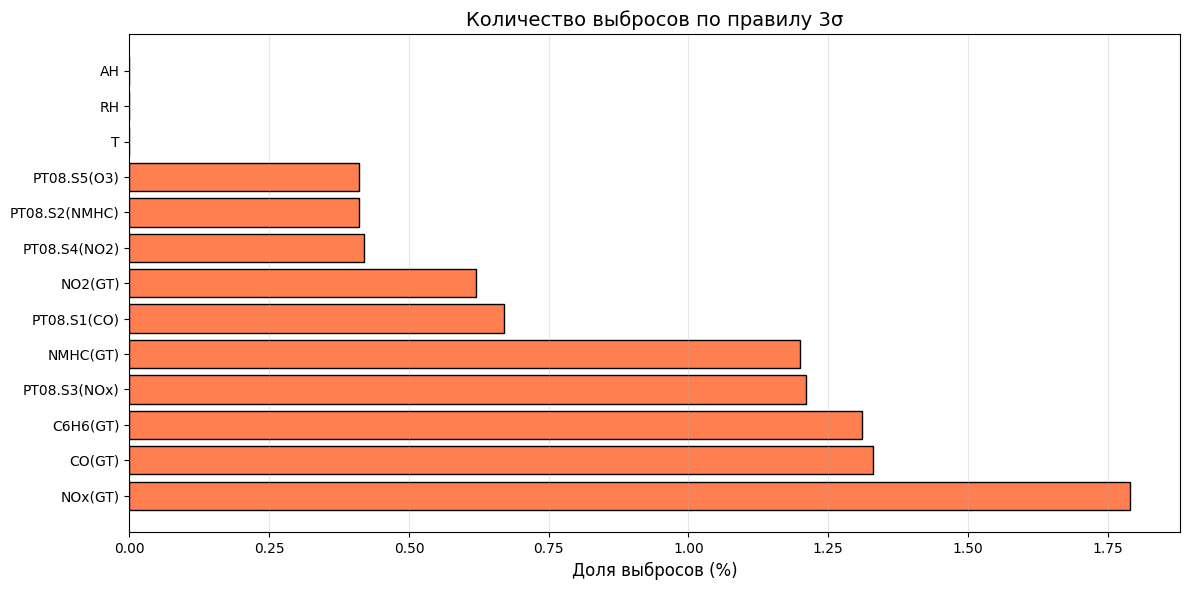

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


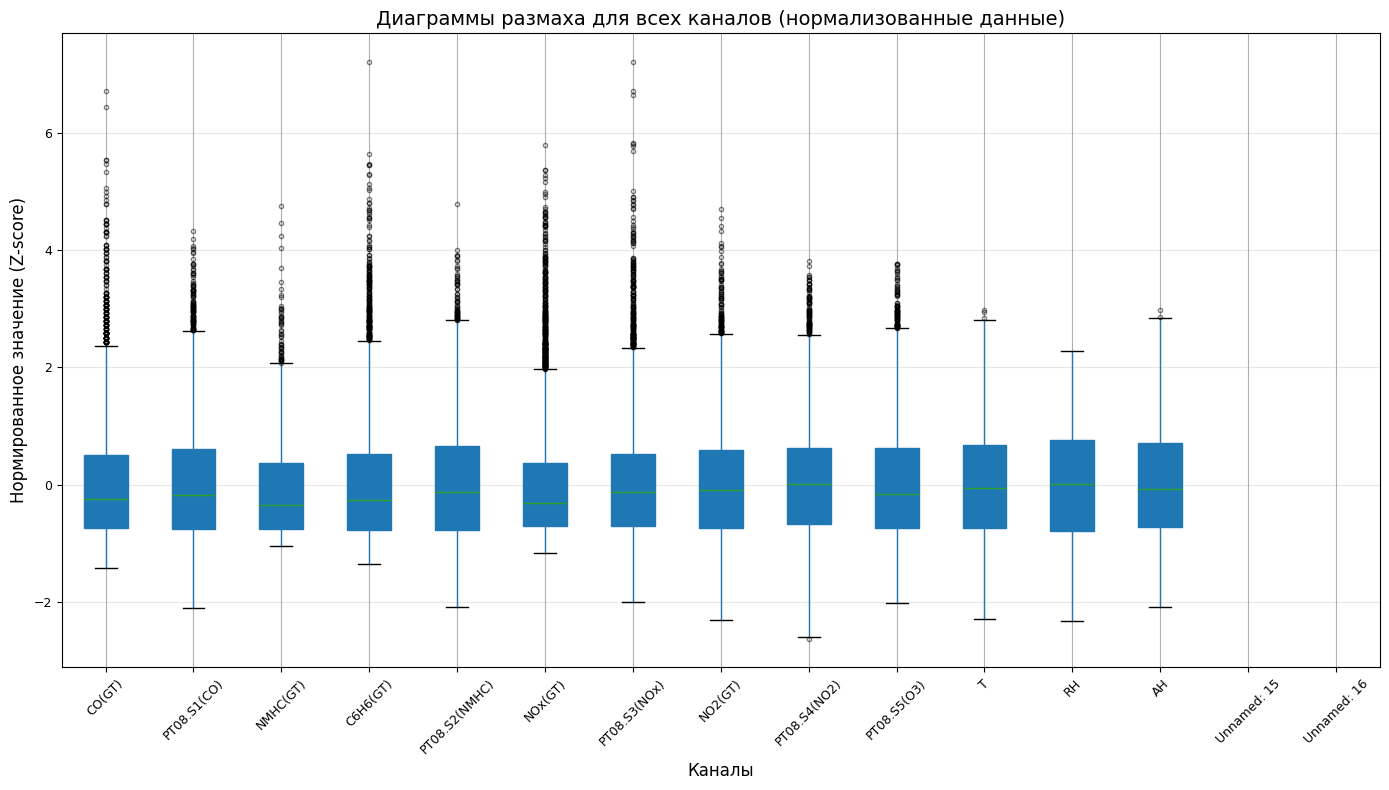

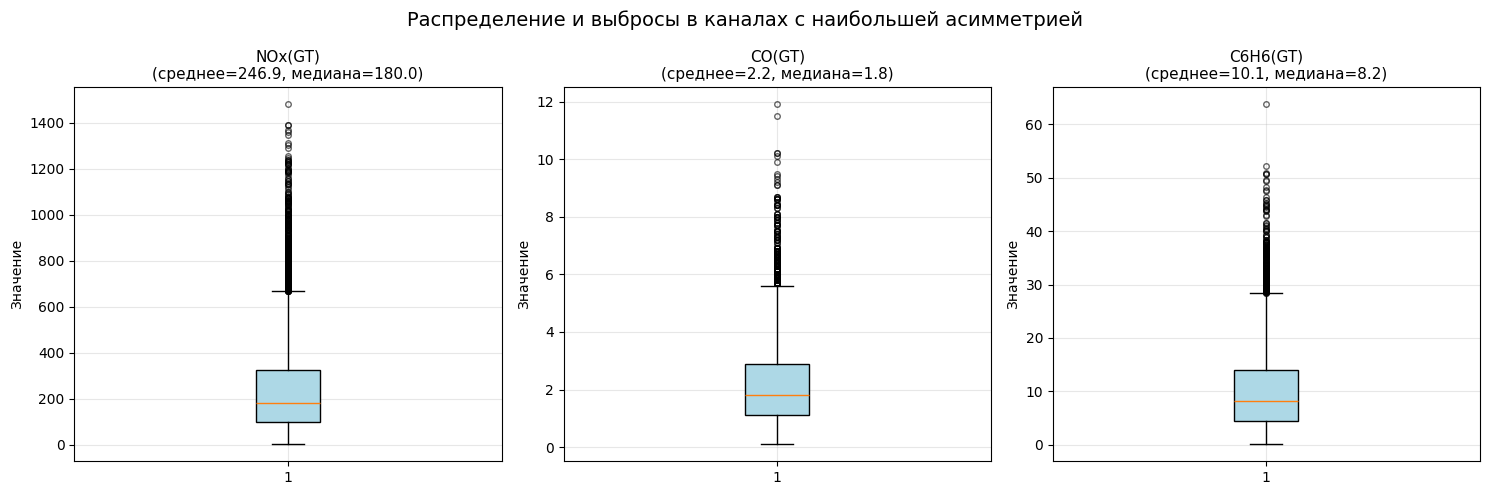

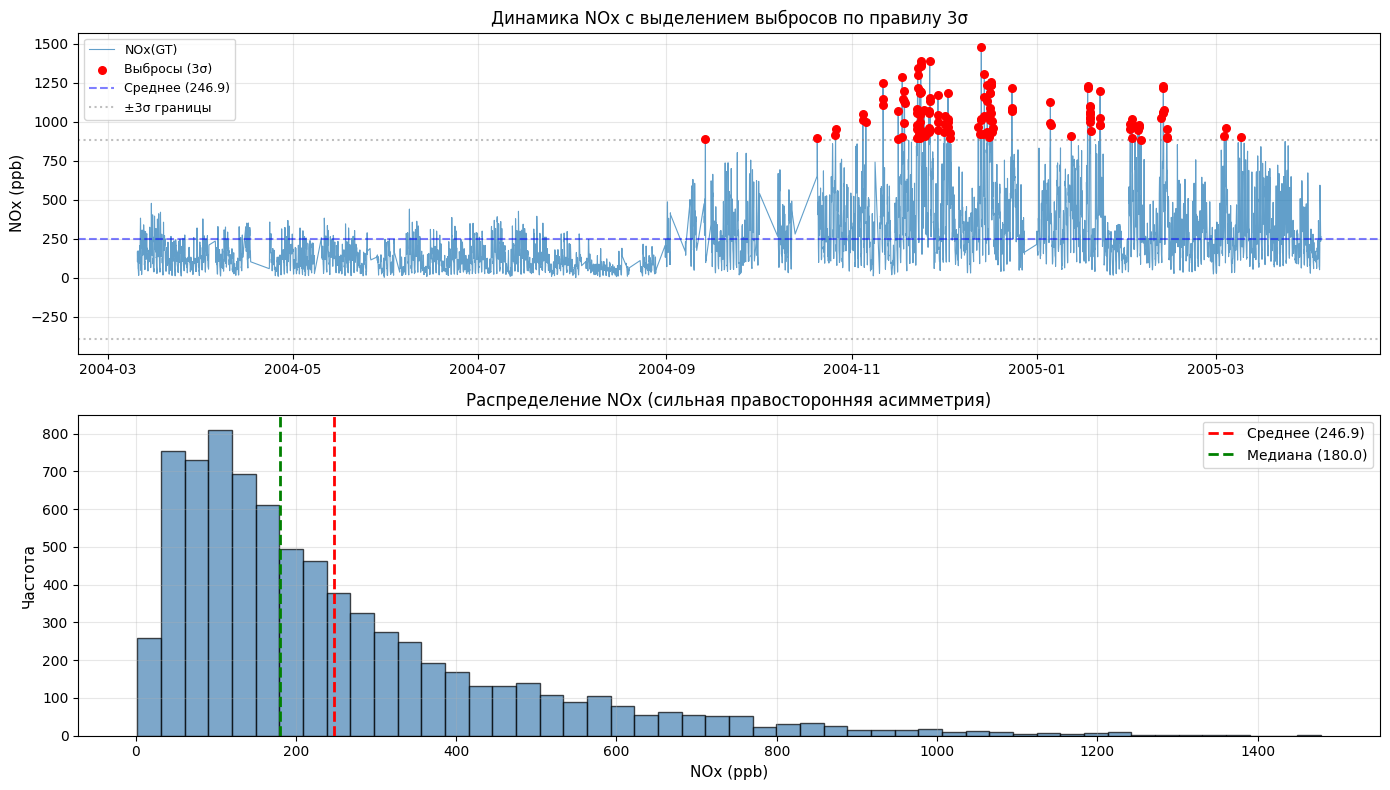

In [ ]:
# Расчёт доли пропусков
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Канал': missing_pct.index,
    'Доля пропусков (%)': missing_pct.values,
    'Количество пропусков': df.isnull().sum().values
}).sort_values('Доля пропусков (%)', ascending=False)

print("Доля пропущенных значений по каналам:")
print(missing_df.to_string(index=False))

# Визуализация пропусков
plt.figure(figsize=(12, 6))
missing_pct.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Доля пропущенных значений (%)', fontsize=12)
plt.title('Пропуски в каналах данных', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ систематичности пропусков во времени
# Создадим признаки времени
df['Hour'] = df.index.hour
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek  # 0=понедельник, 6=воскресенье

# Для каналов с наибольшим количеством пропусков
channels_with_missing = ['NMHC(GT)', 'NOx(GT)', 'NO2(GT)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, channel in enumerate(channels_with_missing):
    # Группировка по часам
    missing_by_hour = df.groupby('Hour')[channel].apply(lambda x: x.isnull().sum() / len(x) * 100)
    axes[idx].plot(missing_by_hour.index, missing_by_hour.values, marker='o', linewidth=2)
    axes[idx].set_title(f'{channel} - Пропуски по часам суток', fontsize=11)
    axes[idx].set_xlabel('Час дня')
    axes[idx].set_ylabel('Доля пропусков (%)')
    axes[idx].grid(True, alpha=0.3)

# Объединённый график
for channel in channels_with_missing:
    missing_by_hour = df.groupby('Hour')[channel].apply(lambda x: x.isnull().sum() / len(x) * 100)
    axes[3].plot(missing_by_hour.index, missing_by_hour.values, marker='o', label=channel, linewidth=2)
axes[3].set_title('Сравнение пропусков по часам', fontsize=11)
axes[3].set_xlabel('Час дня')
axes[3].set_ylabel('Доля пропусков (%)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Функция для подсчёта выбросов по правилу 3 сигм
def count_outliers_3sigma(series):
    """Возвращает количество выбросов по правилу трёх сигм (для нормального распределения)"""
    mean = series.mean()
    std = series.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), outliers.dropna().tolist()[:5]  # первые 5 примеров

# Расчёт выбросов для всех каналов
outliers_results = []
for column in df.columns:
    if column not in ['Hour', 'Month', 'DayOfWeek']:  # исключаем временные признаки
        series = df[column].dropna()
        if len(series) > 0:
            count, examples = count_outliers_3sigma(series)
            outliers_results.append({
                'Канал': column,
                'Выбросов (3σ)': count,
                'Доля выбросов (%)': round(count / len(series) * 100, 2),
                'Примеры выбросов': str(examples)[:50] + '...' if len(str(examples)) > 50 else str(examples)
            })

outliers_df = pd.DataFrame(outliers_results)
outliers_df = outliers_df.sort_values('Доля выбросов (%)', ascending=False)
print("Выбросы по правилу трёх сигм:")
print(outliers_df.to_string(index=False))

# Визуализация выбросов
plt.figure(figsize=(12, 6))
bars = plt.barh(outliers_df['Канал'], outliers_df['Доля выбросов (%)'],
                color='coral', edgecolor='black')
plt.xlabel('Доля выбросов (%)', fontsize=12)
plt.title('Количество выбросов по правилу 3σ', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 4.1. Boxplot для всех каналов (с нормализацией для сравнения)
from sklearn.preprocessing import StandardScaler

# Нормализуем данные для сравнения на одном графике
df_for_boxplot = df.drop(columns=['Hour', 'Month', 'DayOfWeek'], errors='ignore')
scaler = StandardScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_for_boxplot),
    columns=df_for_boxplot.columns,
    index=df_for_boxplot.index
)

plt.figure(figsize=(14, 8))
df_normalized.boxplot(rot=45, fontsize=9, grid=True, patch_artist=True,
                       flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
plt.title('Диаграммы размаха для всех каналов (нормализованные данные)', fontsize=14)
plt.ylabel('Нормированное значение (Z-score)', fontsize=12)
plt.xlabel('Каналы', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2. Отдельные boxplot для каналов с большим количеством выбросов
channels_high_outliers = outliers_df[outliers_df['Доля выбросов (%)'] > 2]['Канал'].tolist()
if len(channels_high_outliers) < 3:
    channels_high_outliers = outliers_df.head(3)['Канал'].tolist()

fig, axes = plt.subplots(1, len(channels_high_outliers), figsize=(15, 5))
if len(channels_high_outliers) == 1:
    axes = [axes]

for idx, channel in enumerate(channels_high_outliers):
    data = df[channel].dropna()
    axes[idx].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'),
                       flierprops=dict(marker='o', markersize=4, alpha=0.6))
    axes[idx].set_title(f'{channel}\n(среднее={data.mean():.1f}, медиана={data.median():.1f})', fontsize=11)
    axes[idx].set_ylabel('Значение', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение и выбросы в каналах с наибольшей асимметрией', fontsize=14)
plt.tight_layout()
plt.show()

# 4.3. Динамика выбросов во времени (для NOx как примера)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Временной ряд NOx с выделением выбросов
channel = 'NOx(GT)'
series = df[channel].dropna()
mean = series.mean()
std = series.std()
median = series.median()
outliers_mask = (series < mean - 3*std) | (series > mean + 3*std)

axes[0].plot(series.index, series.values, linewidth=0.8, alpha=0.7, label='NOx(GT)')
axes[0].scatter(series[outliers_mask].index, series[outliers_mask].values,
                color='red', s=30, label='Выбросы (3σ)', zorder=5)
axes[0].axhline(y=mean, color='blue', linestyle='--', alpha=0.5, label=f'Среднее ({mean:.1f})')
axes[0].axhline(y=mean + 3*std, color='gray', linestyle=':', alpha=0.5, label='±3σ границы')
axes[0].axhline(y=mean - 3*std, color='gray', linestyle=':', alpha=0.5)
axes[0].set_ylabel('NOx (ppb)', fontsize=11)
axes[0].set_title('Динамика NOx с выделением выбросов по правилу 3σ', fontsize=12)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Гистограмма распределения NOx
axes[1].hist(series.values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(x=mean, color='red', linestyle='--', linewidth=2, label=f'Среднее ({mean:.1f})')
axes[1].axvline(x=median, color='green', linestyle='--', linewidth=2, label=f'Медиана ({median:.1f})')
axes[1].set_xlabel('NOx (ppb)', fontsize=11)
axes[1].set_ylabel('Частота', fontsize=11)
axes[1].set_title('Распределение NOx (сильная правосторонняя асимметрия)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Анализируемые каналы: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Month', 'DayOfWeek']


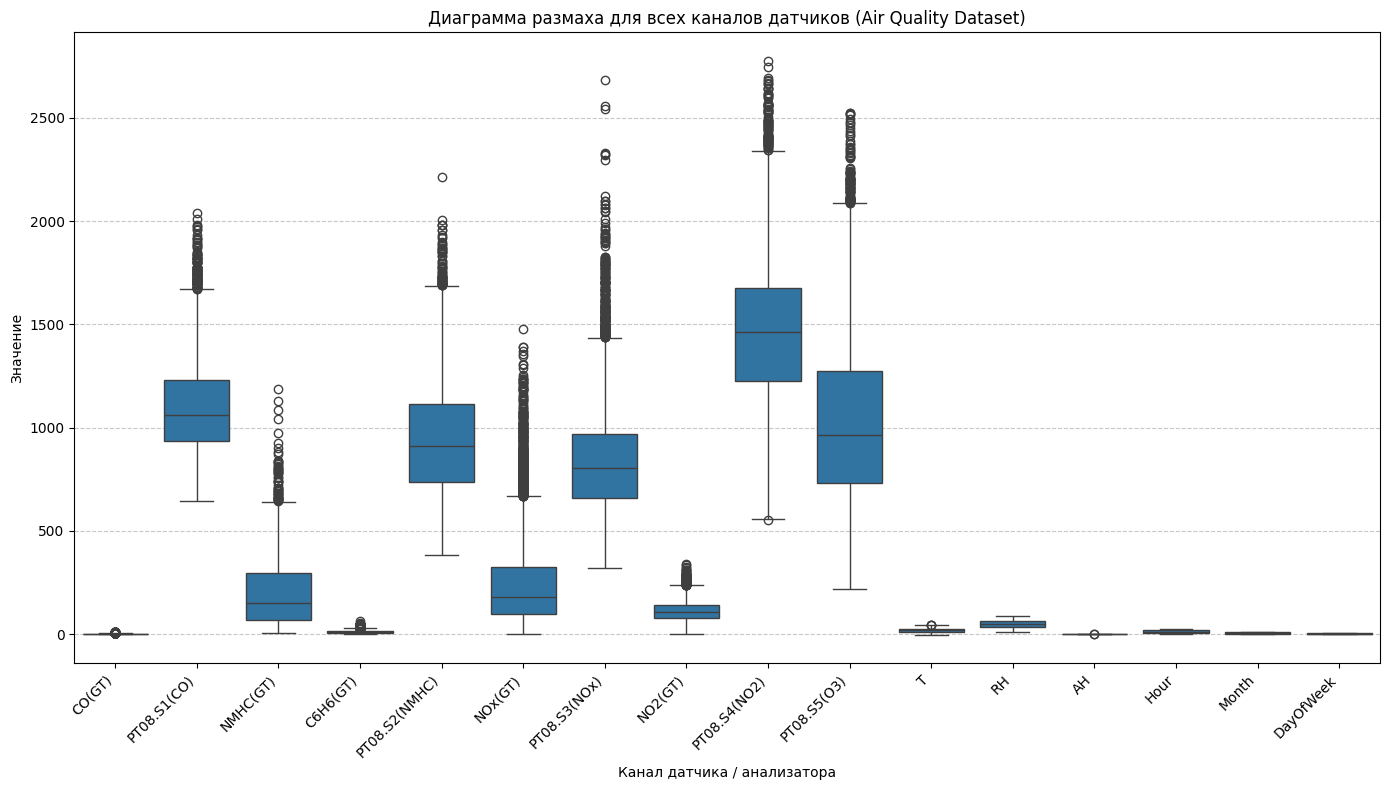


Статистика размаха (min, max, median) по каналам:
                    min       max        50%      range
PT08.S3(NOx)   322.0000  2683.000   806.0000  2361.0000
PT08.S5(O3)    221.0000  2523.000   963.0000  2302.0000
PT08.S4(NO2)   551.0000  2775.000  1463.0000  2224.0000
PT08.S2(NMHC)  383.0000  2214.000   909.0000  1831.0000
NOx(GT)          2.0000  1479.000   180.0000  1477.0000
PT08.S1(CO)    647.0000  2040.000  1063.0000  1393.0000
NMHC(GT)         7.0000  1189.000   150.0000  1182.0000
NO2(GT)          2.0000   340.000   109.0000   338.0000
RH               9.2000    88.700    49.6000    79.5000
C6H6(GT)         0.1000    63.700     8.2000    63.6000
T               -1.9000    44.600    17.8000    46.5000
Hour             0.0000    23.000    11.0000    23.0000
CO(GT)           0.1000    11.900     1.8000    11.8000
Month            1.0000    12.000     6.0000    11.0000
DayOfWeek        0.0000     6.000     3.0000     6.0000
AH               0.1847     2.231     0.9954     2.04

In [ ]:
import seaborn as sns

# 1. Выбор числовых каналов для анализа (все колонки, кроме Date, Time)
channels = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Убираем явно неинформативные колонки, если они есть (например, индексы)
channels = [col for col in channels if col not in ['Unnamed: 15', 'Unnamed: 16']]

print(f"\nАнализируемые каналы: {channels}")

# 2. Приведение данных к длинному формату для boxplot
df_melted = df[channels].melt(var_name='Sensor', value_name='Concentration')
df_melted = df_melted.dropna()  # удаляем пропуски (-200)

# 3. Построение общей диаграммы размаха
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x='Sensor', y='Concentration')
plt.xticks(rotation=45, ha='right')
plt.title('Диаграмма размаха для всех каналов датчиков (Air Quality Dataset)')
plt.ylabel('Значение')
plt.xlabel('Канал датчика / анализатора')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Вывод статистики для сравнения масштабов
print("\nСтатистика размаха (min, max, median) по каналам:")
stats = df[channels].describe().loc[['min', 'max', '50%']].T
stats['range'] = stats['max'] - stats['min']
print(stats.sort_values('range', ascending=False))


МАТРИЦА КОРРЕЛЯЦИЙ ПИРСОНА
               CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T     RH     AH  Unnamed: 15  Unnamed: 16   Hour  Month  DayOfWeek
CO(GT)          1.000        0.879     0.890     0.931          0.916    0.795        -0.703    0.683         0.631        0.854  0.022  0.049  0.049          NaN          NaN  0.358  0.111     -0.127
PT08.S1(CO)     0.879        1.000     0.791     0.884          0.893    0.714        -0.772    0.642         0.683        0.899  0.049  0.115  0.135          NaN          NaN  0.328 -0.040     -0.066
NMHC(GT)        0.890        0.791     1.000     0.903          0.878    0.813        -0.771    0.731         0.853        0.767  0.392 -0.191  0.270          NaN          NaN  0.327  0.207     -0.074
C6H6(GT)        0.931        0.884     0.903     1.000          0.982    0.719        -0.736    0.614         0.766        0.866  0.199 -0.062  0.168          NaN      

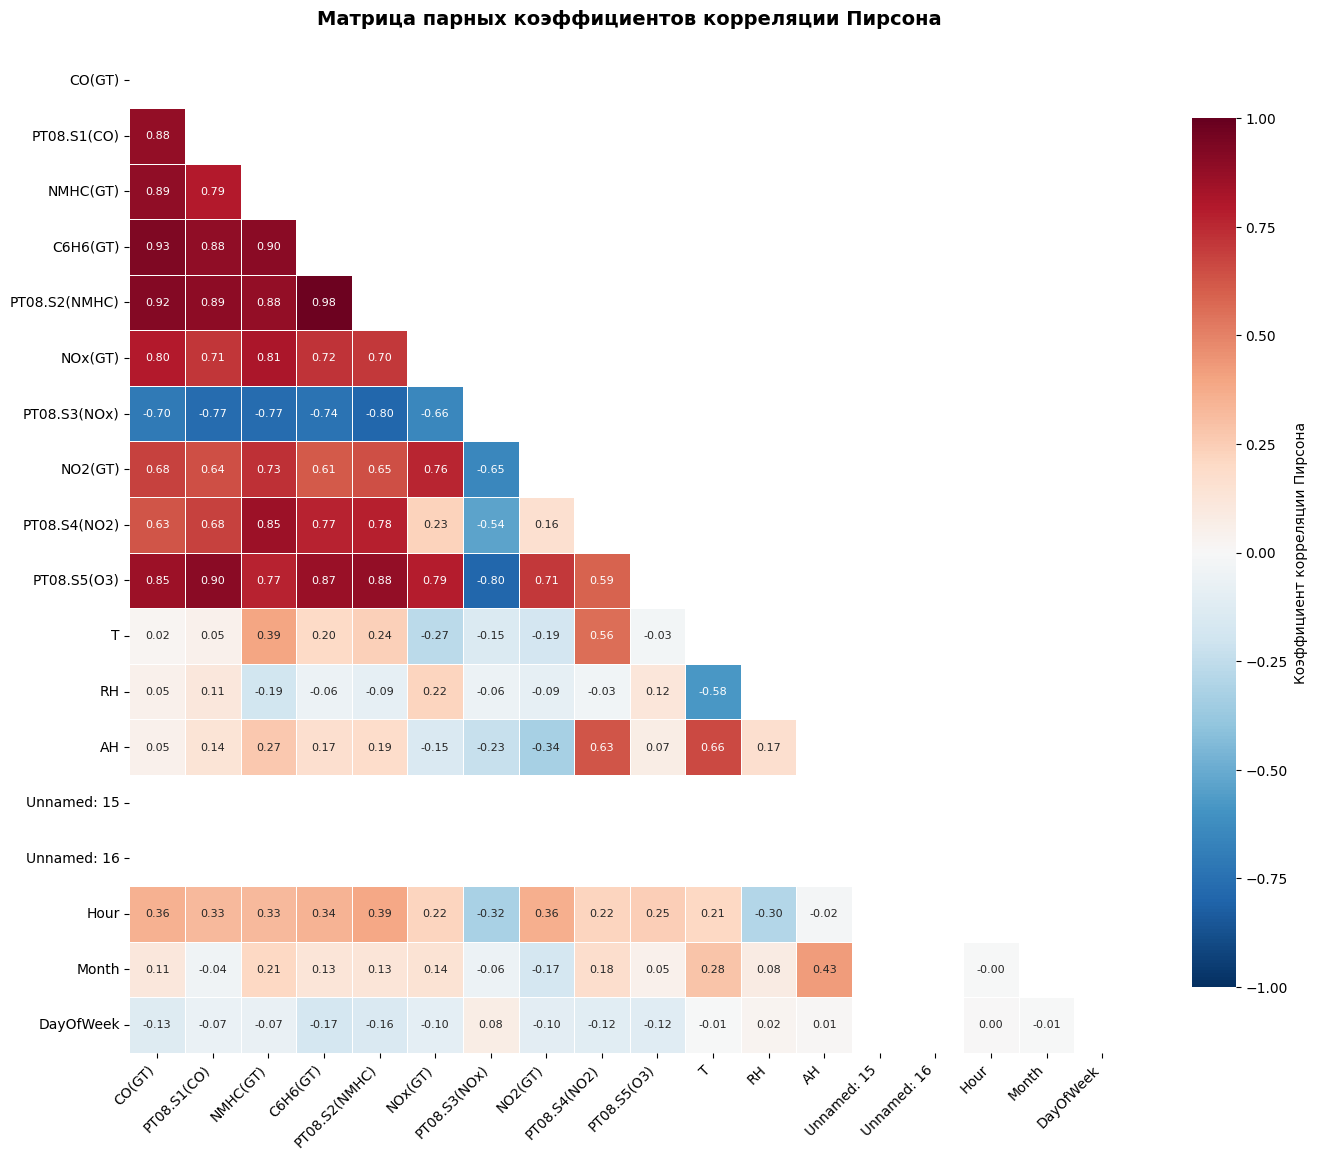


ТОП-15 НАИБОЛЕЕ СИЛЬНЫХ КОРРЕЛЯЦИЙ (по абсолютному значению)
  ⊕ C6H6(GT)             ↔ PT08.S2(NMHC)        : +0.982 (Очень сильная)
  ⊕ CO(GT)               ↔ C6H6(GT)             : +0.931 (Очень сильная)
  ⊕ CO(GT)               ↔ PT08.S2(NMHC)        : +0.916 (Очень сильная)
  ⊕ NMHC(GT)             ↔ C6H6(GT)             : +0.903 (Очень сильная)
  ⊕ PT08.S1(CO)          ↔ PT08.S5(O3)          : +0.899 (Сильная)
  ⊕ PT08.S1(CO)          ↔ PT08.S2(NMHC)        : +0.893 (Сильная)
  ⊕ CO(GT)               ↔ NMHC(GT)             : +0.890 (Сильная)
  ⊕ PT08.S1(CO)          ↔ C6H6(GT)             : +0.884 (Сильная)
  ⊕ PT08.S2(NMHC)        ↔ PT08.S5(O3)          : +0.881 (Сильная)
  ⊕ CO(GT)               ↔ PT08.S1(CO)          : +0.879 (Сильная)
  ⊕ NMHC(GT)             ↔ PT08.S2(NMHC)        : +0.878 (Сильная)
  ⊕ C6H6(GT)             ↔ PT08.S5(O3)          : +0.866 (Сильная)
  ⊕ CO(GT)               ↔ PT08.S5(O3)          : +0.854 (Сильная)
  ⊕ NMHC(GT)             ↔ PT08.S4(NO2)    

In [ ]:
from scipy import stats

# ============================================
# 1. ВЫЧИСЛЕНИЕ МАТРИЦЫ КОРРЕЛЯЦИИ ПИРСОНА
# ============================================

# Расчёт корреляционной матрицы
corr_matrix = df.corr(method='pearson')

# Округляем для удобства
corr_matrix_rounded = corr_matrix.round(3)

print("\n" + "="*80)
print("МАТРИЦА КОРРЕЛЯЦИЙ ПИРСОНА")
print("="*80)
print(corr_matrix_rounded.to_string())

# ============================================
# 2. ВИЗУАЛИЗАЦИЯ ТЕПЛОВОЙ КАРТЫ
# ============================================

# Настройка размера фигуры
plt.figure(figsize=(14, 12))

# Тепловая карта с маской верхнего треугольника (для лучшей читаемости)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Расширенная цветовая схема
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,           # показывать значения
            fmt='.2f',            # 2 знака после запятой
            cmap='RdBu_r',        # красный (отр.) - синий (пол.)
            center=0,             # центр цветовой шкалы в 0
            vmin=-1, vmax=1,      # диапазон корреляций
            square=True,          # квадратные ячейки
            linewidths=0.5,       # тонкие линии между ячейками
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции Пирсона"},
            annot_kws={'size': 8})

plt.title('Матрица парных коэффициентов корреляции Пирсона',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# 3. АНАЛИЗ НАИБОЛЕЕ СИЛЬНЫХ КОРРЕЛЯЦИЙ
# ============================================

# Получаем верхний треугольник матрицы (без диагонали)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Находим топ-10 сильнейших корреляций (по абсолютному значению)
stacked_corr = upper_triangle.stack().sort_values(key=abs, ascending=False)
top_correlations = stacked_corr.head(15)

print("\n" + "="*80)
print("ТОП-15 НАИБОЛЕЕ СИЛЬНЫХ КОРРЕЛЯЦИЙ (по абсолютному значению)")
print("="*80)
for (idx, val) in top_correlations.items():
    sign = "⊕" if val > 0 else "⊖"
    strength = "Очень сильная" if abs(val) > 0.9 else "Сильная" if abs(val) > 0.7 else "Умеренная"
    print(f"  {sign} {idx[0]:<20} ↔ {idx[1]:<20} : {val:+.3f} ({strength})")

# ============================================
# 4. КОРРЕЛЯЦИИ С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ
# ============================================

# Определяем целевые переменные (reference газы)
target_cols = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

print("\n" + "="*80)
print("КОРРЕЛЯЦИИ С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ (reference газы)")
print("="*80)

for target in target_cols:
    print(f"\nЦелевая переменная: {target}")
    print("-" * 50)
    correlations = corr_matrix[target].sort_values(ascending=False)
    for idx, val in correlations.items():
        if idx != target:
            symbol = "⊕" if val > 0 else "⊖"
            strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.5 else "слабая"
            print(f"  {symbol} {idx:<20}: {val:+.3f} ({strength})")

# ============================================
# 5. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ
# ============================================

print("\n" + "="*80)
print("АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ")
print("="*80)

# Находим пары с корреляцией > 0.85 (сильная мультиколлинеарность)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_val
            })

if high_corr_pairs:
    print("\nПары с очень сильной корреляцией (>0.85):")
    for pair in high_corr_pairs:
        print(f"  {pair['Признак 1']} ↔ {pair['Признак 2']}: {pair['Корреляция']:.3f}")
else:
    print("\nНет пар с корреляцией > 0.85")


Выбран канал: CO(GT)
Длина ряда: 9471
Количество пропусков: 1797 (18.97%)
Временной диапазон: 2004-03-10 18:00:00 - 2005-04-04 14:00:00
Предупреждение: осталось 1283 пропусков. Заполняем forward fill.

После интерполяции пропусков: 0 пропусков

Корреляция между скользящим std и средним: 0.580
Выбрана мультипликативная модель (амплитуда сезонности зависит от уровня ряда)
Период сезонности: 24 часа (суточная сезонность)

Результаты декомпозиции:
  Тренд: 0 пропусков (края)
  Сезонность: 0 пропусков
  Остатки: 0 пропусков


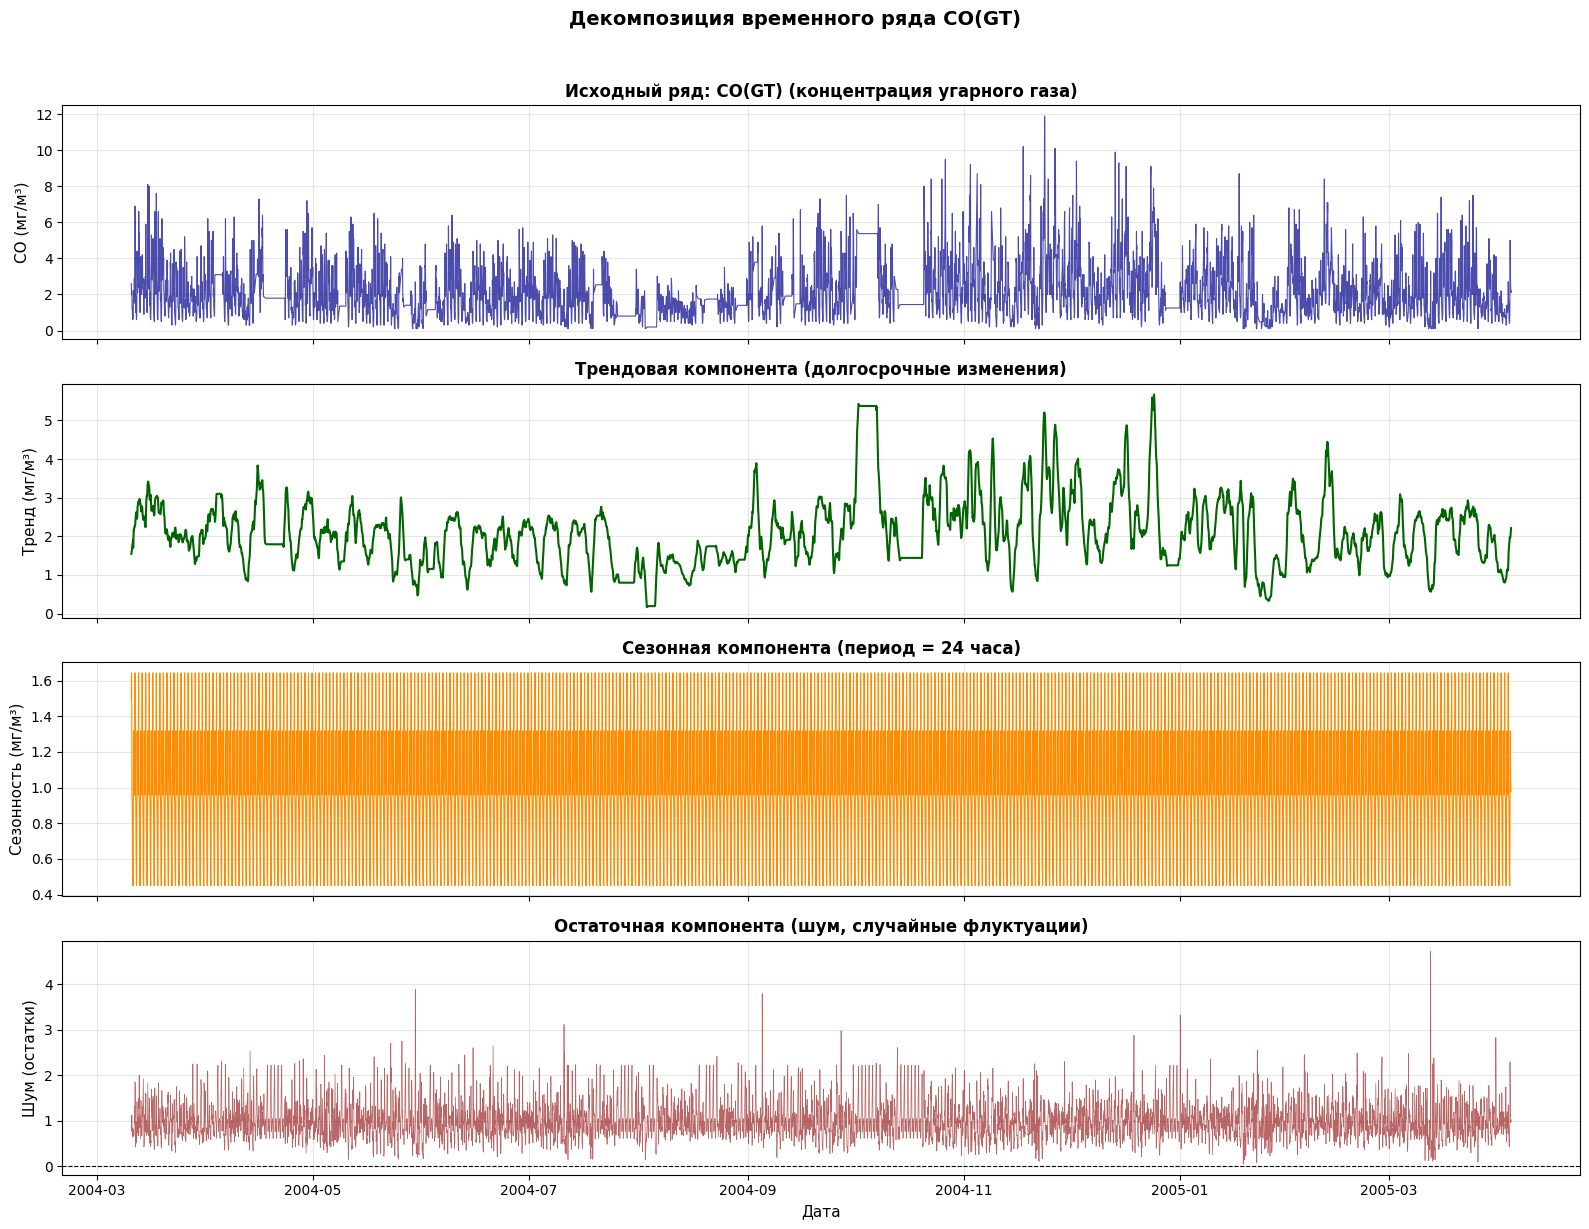


Сигнал (мультипликативная модель): сигнал = тренд × сезонность


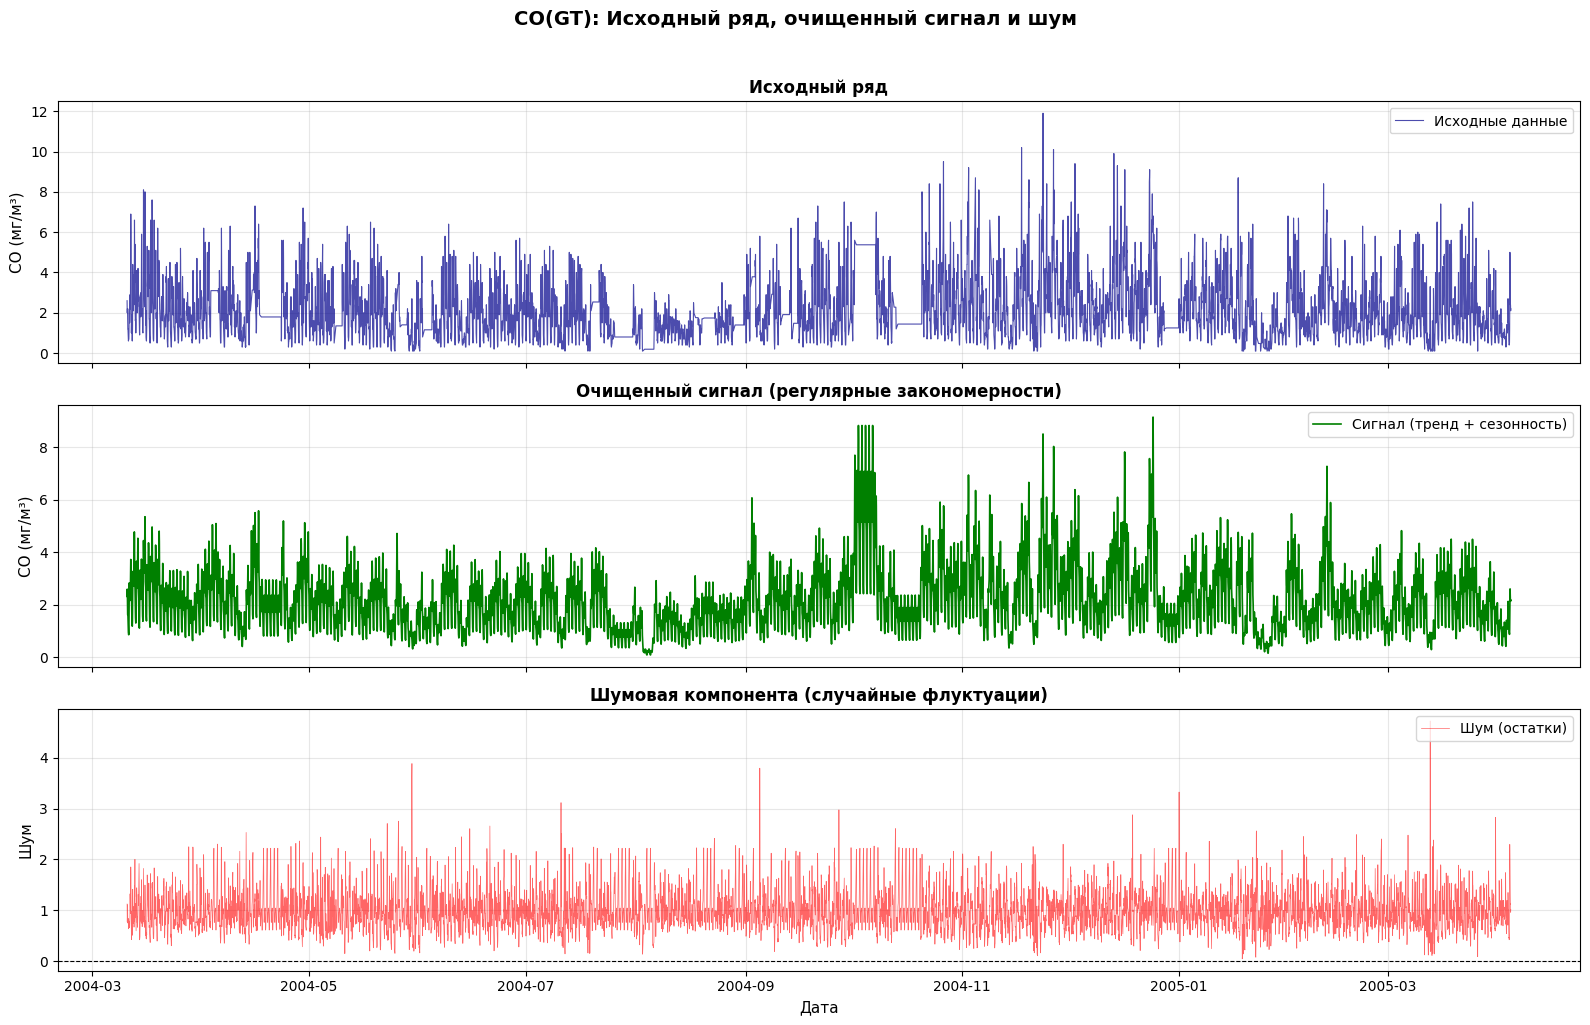


РАСЧЁТ SNR (SIGNAL-TO-NOISE RATIO)
Дисперсия сигнала (σ²_сигнал): 1.362545
Дисперсия шума (σ²_шум): 0.155866
Отношение сигнал/шум (мощность): 8.74
SNR = 10 * log10(σ²_сигнал / σ²_шум) = 9.42

Интерпретация SNR (9.42): Умеренное качество сигнала (шум заметен, но не доминирует)


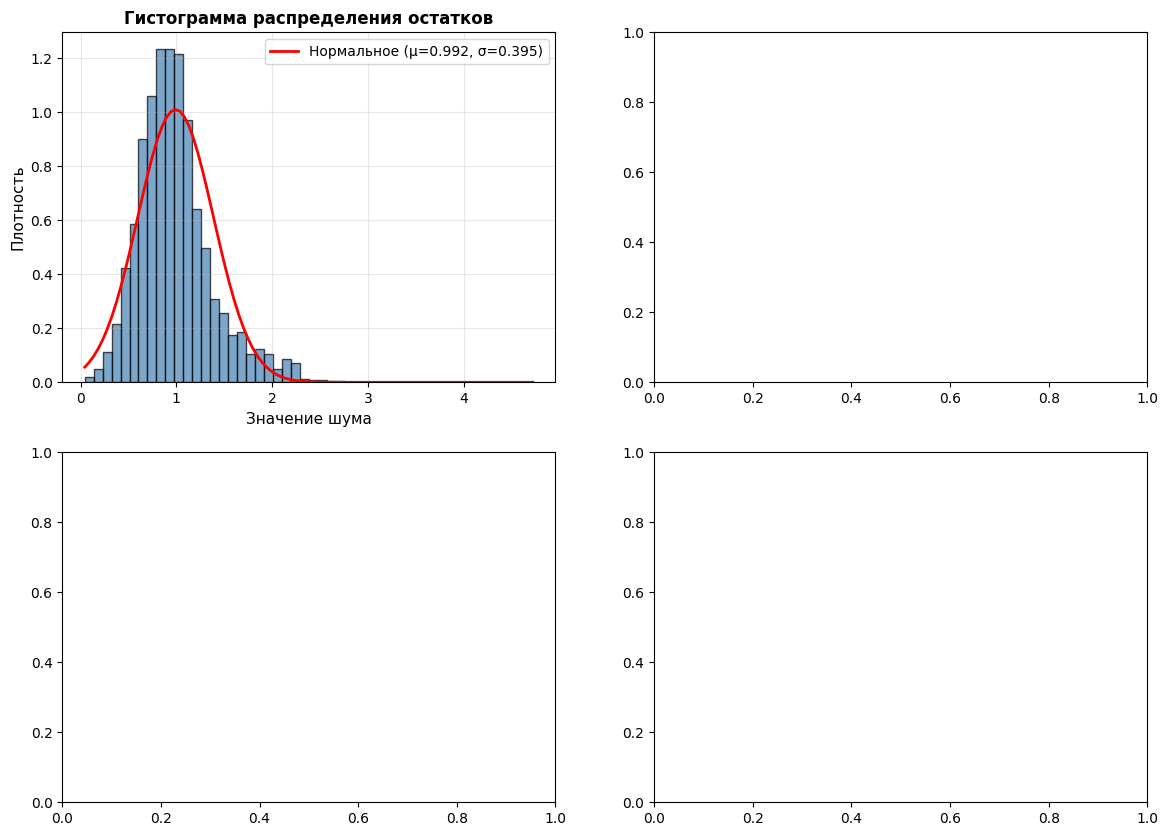

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Выбираем ключевой канал - CO(GT)
channel_name = 'CO(GT)'
series = df[channel_name].copy()

print(f"Выбран канал: {channel_name}")
print(f"Длина ряда: {len(series)}")
print(f"Количество пропусков: {series.isnull().sum()} ({series.isnull().sum()/len(series)*100:.2f}%)")
print(f"Временной диапазон: {series.index.min()} - {series.index.max()}")

# ============================================
# 1. ПОДГОТОВКА РЯДА ДЛЯ ДЕКОМПОЗИЦИИ
# ============================================

# Интерполяция пропусков для декомпозиции (сезонная декомпозиция требует непрерывного ряда)
series_interpolated = series.interpolate(method='linear', limit=12)

# Проверяем остались ли пропуски
if series_interpolated.isnull().any():
    print(f"Предупреждение: осталось {series_interpolated.isnull().sum()} пропусков. Заполняем forward fill.")
    series_interpolated = series_interpolated.fillna(method='ffill').fillna(method='bfill')

print(f"\nПосле интерполяции пропусков: {series_interpolated.isnull().sum()} пропусков")

# ============================================
# 2. ВЫБОР МОДЕЛИ ДЕКОМПОЗИЦИИ
# ============================================

# Определяем подходящую модель (аддитивная или мультипликативная)
# Проверяем, зависит ли амплитуда сезонных колебаний от уровня ряда
rolling_std = series_interpolated.rolling(window=24, center=True).std()
rolling_mean = series_interpolated.rolling(window=24, center=True).mean()

# Если std пропорционален mean -> мультипликативная модель
corr_std_mean = rolling_std.corr(rolling_mean)

print(f"\nКорреляция между скользящим std и средним: {corr_std_mean:.3f}")

if corr_std_mean > 0.3:
    model_type = 'multiplicative'
    print(f"Выбрана мультипликативная модель (амплитуда сезонности зависит от уровня ряда)")
else:
    model_type = 'additive'
    print(f"Выбрана аддитивная модель (амплитуда сезонности постоянна)")

# Период сезонности: 24 (суточная) или 168 (недельная)
# Для почасовых данных качества воздуха наиболее выражена суточная сезонность
period = 24
print(f"Период сезонности: {period} часа (суточная сезонность)")

# ============================================
# 3. ВЫПОЛНЕНИЕ ДЕКОМПОЗИЦИИ
# ============================================

# Декомпозиция ряда
decomposition = seasonal_decompose(
    series_interpolated,
    model=model_type,
    period=period,
    extrapolate_trend='freq'  # для обработки краевых эффектов
)

# Извлечение компонент
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print(f"\nРезультаты декомпозиции:")
print(f"  Тренд: {trend.isnull().sum()} пропусков (края)")
print(f"  Сезонность: {seasonal.isnull().sum()} пропусков")
print(f"  Остатки: {residual.isnull().sum()} пропусков")

# ============================================
# 4. ВИЗУАЛИЗАЦИЯ ДЕКОМПОЗИЦИИ
# ============================================

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Исходный ряд
axes[0].plot(series_interpolated.index, series_interpolated.values,
             linewidth=0.8, color='darkblue', alpha=0.7)
axes[0].set_ylabel('CO (мг/м³)', fontsize=11)
axes[0].set_title(f'Исходный ряд: {channel_name} (концентрация угарного газа)',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Тренд
axes[1].plot(trend.index, trend.values, linewidth=1.5, color='darkgreen')
axes[1].set_ylabel('Тренд (мг/м³)', fontsize=11)
axes[1].set_title('Трендовая компонента (долгосрочные изменения)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Сезонность
axes[2].plot(seasonal.index, seasonal.values, linewidth=0.8, color='darkorange')
axes[2].set_ylabel('Сезонность (мг/м³)', fontsize=11)
axes[2].set_title(f'Сезонная компонента (период = {period} часа)',
                  fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Остатки (шум)
axes[3].plot(residual.index, residual.values, linewidth=0.5, color='darkred', alpha=0.6)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Шум (остатки)', fontsize=11)
axes[3].set_xlabel('Дата', fontsize=11)
axes[3].set_title('Остаточная компонента (шум, случайные флуктуации)',
                  fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Декомпозиция временного ряда {channel_name}', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 5. ФОРМИРОВАНИЕ СИГНАЛА (ОЧИЩЕННЫЙ ОТ ШУМА)
# ============================================

if model_type == 'additive':
    signal = trend + seasonal
    print(f"\nСигнал (аддитивная модель): сигнал = тренд + сезонность")
else:
    signal = trend * seasonal
    print(f"\nСигнал (мультипликативная модель): сигнал = тренд × сезонность")

# Удаляем NaN (края)
signal_clean = signal.dropna()
residual_clean = residual.dropna()

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ: ИСХОДНЫЙ РЯД, СИГНАЛ, ШУМ
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Исходный ряд
axes[0].plot(series_interpolated.index, series_interpolated.values,
             linewidth=0.8, color='darkblue', alpha=0.7, label='Исходные данные')
axes[0].set_ylabel('CO (мг/м³)', fontsize=11)
axes[0].set_title('Исходный ряд', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Сигнал (очищенный от шума)
axes[1].plot(signal.index, signal.values, linewidth=1.2, color='green', label='Сигнал (тренд + сезонность)')
axes[1].set_ylabel('CO (мг/м³)', fontsize=11)
axes[1].set_title('Очищенный сигнал (регулярные закономерности)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Шум
axes[2].plot(residual.index, residual.values, linewidth=0.5, color='red', alpha=0.6, label='Шум (остатки)')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Шум', fontsize=11)
axes[2].set_xlabel('Дата', fontsize=11)
axes[2].set_title('Шумовая компонента (случайные флуктуации)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{channel_name}: Исходный ряд, очищенный сигнал и шум',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. РАСЧЁТ SNR (SIGNAL-TO-NOISE RATIO)
# ============================================

# Дисперсия сигнала и шума
var_signal = signal_clean.var()
var_noise = residual_clean.var()

# SNR
SNR = 10 * np.log10(var_signal / var_noise)

print("\n" + "="*60)
print("РАСЧЁТ SNR (SIGNAL-TO-NOISE RATIO)")
print("="*60)
print(f"Дисперсия сигнала (σ²_сигнал): {var_signal:.6f}")
print(f"Дисперсия шума (σ²_шум): {var_noise:.6f}")
print(f"Отношение сигнал/шум (мощность): {var_signal/var_noise:.2f}")
print(f"SNR = 10 * log10(σ²_сигнал / σ²_шум) = {SNR:.2f}")

# Интерпретация SNR
if SNR > 20:
    snr_interpret = "Очень высокое качество сигнала (шум почти незаметен)"
elif SNR > 10:
    snr_interpret = "Хорошее качество сигнала (шум слабо влияет на закономерности)"
elif SNR > 0:
    snr_interpret = "Умеренное качество сигнала (шум заметен, но не доминирует)"
else:
    snr_interpret = "Низкое качество сигнала (шум сопоставим или превышает сигнал)"

print(f"\nИнтерпретация SNR ({SNR:.2f}): {snr_interpret}")

# ============================================
# 8. АНАЛИЗ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ (ШУМА)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма остатков
axes[0, 0].hist(residual_clean.values, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
axes[0, 0].set_xlabel('Значение шума', fontsize=11)
axes[0, 0].set_ylabel('Плотность', fontsize=11)
axes[0, 0].set_title('Гистограмма распределения остатков', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Нормальное распределение для сравнения
x = np.linspace(residual_clean.min(), residual_clean.max(), 100)
mu, std = stats.norm.fit(residual_clean.dropna())
normal_pdf = stats.norm.pdf(x, mu, std)
axes[0, 0].plot(x, normal_pdf, 'r-', linewidth=2, label=f'Нормальное (μ={mu:.3f}, σ={std:.3f})')
axes[0, 0].legend()

